# Домашнее задание по теме "Архитектура сверточных сетей"

## Задание

Проведите эксперименты по начальному обучению различных моделей и сравните результаты.

1. Возьмите датасет EMNIST из torchvision.
1. Обучите на нём модели: ResNet 18, VGG 16, Inception v3, DenseNet 161:
    - желательно обучить каждую модель с нуля по 10 эпох
    - если ресурсов компьютера / Colab не хватает, достаточно обучить каждую модель по 1-2 эпохи
1. Сведите результаты обучения моделей (графики лосса) в таблицу и сравните их.

In [17]:
from collections import Counter
import pandas as pd
import torch
from torch import nn
import torchvision as tv
import torchvision.models as models
from torchsummary import summary
import time
import gc

### 1. Загрузка и предобработка данных

In [ ]:
transoforms = tv.transforms.Compose([
    tv.transforms.Resize((32, 32)),
    tv.transforms.ToTensor()
])
train_dataset = tv.datasets.EMNIST('datas/', split='balanced', train=True, transform=transoforms, download=True)
test_dataset = tv.datasets.EMNIST('datas/', split='balanced', train=False, transform=transoforms, download=True)

#### Изучаем датасет

In [3]:
# Размеры выборок
print(f"Размер тренировочной выборки: {len(train_dataset)}")
print(f"Размер тестовой выборки: {len(test_dataset)}")

Размер тренировочной выборки: 112800
Размер тестовой выборки: 18800


In [4]:
# Количество классов
classes = train_dataset.classes
print(f"Количество классов: {len(classes)}")

Количество классов: 47


Проверка баланса классов

In [5]:
labels = train_dataset.targets.numpy()
counts = Counter(labels)

for i in range(len(classes)):
    print(f"Класс {classes[i]}: {counts[i]} примеров")

Класс 0: 2400 примеров
Класс 1: 2400 примеров
Класс 2: 2400 примеров
Класс 3: 2400 примеров
Класс 4: 2400 примеров
Класс 5: 2400 примеров
Класс 6: 2400 примеров
Класс 7: 2400 примеров
Класс 8: 2400 примеров
Класс 9: 2400 примеров
Класс A: 2400 примеров
Класс B: 2400 примеров
Класс C: 2400 примеров
Класс D: 2400 примеров
Класс E: 2400 примеров
Класс F: 2400 примеров
Класс G: 2400 примеров
Класс H: 2400 примеров
Класс I: 2400 примеров
Класс J: 2400 примеров
Класс K: 2400 примеров
Класс L: 2400 примеров
Класс M: 2400 примеров
Класс N: 2400 примеров
Класс O: 2400 примеров
Класс P: 2400 примеров
Класс Q: 2400 примеров
Класс R: 2400 примеров
Класс S: 2400 примеров
Класс T: 2400 примеров
Класс U: 2400 примеров
Класс V: 2400 примеров
Класс W: 2400 примеров
Класс X: 2400 примеров
Класс Y: 2400 примеров
Класс Z: 2400 примеров
Класс a: 2400 примеров
Класс b: 2400 примеров
Класс d: 2400 примеров
Класс e: 2400 примеров
Класс f: 2400 примеров
Класс g: 2400 примеров
Класс h: 2400 примеров
Класс n: 24

Итог: Классы сбалансированы

#### Структура одного объекта

In [6]:
image, label = train_dataset[0] # Берем первый элемент

print(f"Тип данных изображения: {type(image)}")
print(f"Формат (Shape) изображения: {image.shape}")
print(f"Метка (Label): {label}")
print(f"Название класса: {classes[label]}")

# Проверим диапазон значений пикселей
print(f"Минимальное значение пикселя: {image.min()}")
print(f"Максимальное значение пикселя: {image.max()}")

Тип данных изображения: <class 'torch.Tensor'>
Формат (Shape) изображения: torch.Size([1, 224, 224])
Метка (Label): 45
Название класса: r
Минимальное значение пикселя: 0.0
Максимальное значение пикселя: 1.0


#### Визуализация

In [7]:
import matplotlib.pyplot as plt

def show_images(dataset, num_images=10):
    plt.figure(figsize=(15, 5))
    for i in range(num_images):
        img, label = dataset[i]
        img_display = img.permute(1, 2, 0).numpy()
        
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img_display, cmap='gray')
        plt.title(classes[label])
        plt.axis('off')
    plt.show()

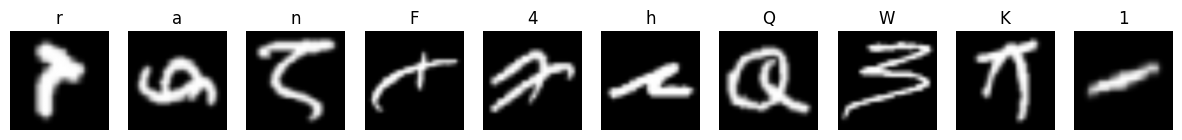

In [8]:
show_images(train_dataset)

#### Создание итераторов для обучающей и тестовой выборок

In [ ]:
BATCH_SIZE = 64

train_iter = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)
test_iter = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=4,
    pin_memory=True
)

### 2. Вспомогательные функции

Выбираем устройство, на котором будет проводиться обучение

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

Функция для оценки качества работы нейронных сетей

In [7]:
def evaluate_model(data_iter, net, loss, device):
    acc_sum, n = 0, 0
    net.eval()
    loss_sum = 0.0
    acc_sum = 0.0
    n = 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            outputs = net(X)
            l = loss(outputs, y)
            loss_sum += l.item() * y.shape[0]
            acc_sum += (outputs.argmax(axis=1) == y).sum().item()
            n += y.shape[0]
    return acc_sum / n, loss_sum / n

 Функция визуализации кривых обучения

In [9]:
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(12, 5))

    # График Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'bo-', label='Train Loss')
    plt.plot(epochs, history['test_loss'], 'ro-', label='Test Loss')
    plt.title('Training and Test Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()

    # График Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'bo-', label='Train Acc')
    plt.plot(epochs, history['test_acc'], 'ro-', label='Test Acc')
    plt.title('Training and Test Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()

    plt.show()

Функция для обучения нейронной сети

In [10]:
def train(net, train_iter, test_iter, trainer, num_epochs, device):
    net.to(device)
    loss = nn.CrossEntropyLoss()
    history = {
        'train_loss': [], 'train_acc': [],
        'test_loss': [], 'test_acc': []
    }
    net.train()
    print(f"Начинаем обучение на {device}")
    print('-' * 20)
    
    for epoch in range(num_epochs):
        train_l_sum, train_acc_sum, n, start = 0.0, 0.0, 0, time.time()
        
        for i, (X, y) in enumerate(train_iter):
            X, y = X.to(device), y.to(device)
            trainer.zero_grad()
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            trainer.step()
            train_l_sum += l.item() * X.shape[0]
            train_acc_sum += (y_hat.argmax(axis=1) == y).sum().item()
            n += y.shape[0]
            
        test_acc, test_loss = evaluate_model(test_iter, net.to(device), loss, device)

        epoch_train_loss = train_l_sum / n
        epoch_train_acc = train_acc_sum / n
        
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        print(f'Эпоха {epoch + 1}, loss {train_l_sum / n:.4f}, train acc {train_acc_sum / n:.3f}'
              f', test acc {test_acc:.3f}, time {time.time() - start:.1f} sec')
        
    plot_history(history)
    return history    

Функция для построения таблицы сравнения работы моделей

In [11]:
# Создаем пустой список для хранения результатов
results_list = []

def add_to_results(model_name, history):
    results_list.append({
        'Model': model_name,
        'Train Loss': history['train_loss'][-1],
        'Train Acc': history['train_acc'][-1],
        'Test Loss': history['test_loss'][-1],
        'Test Acc': history['test_acc'][-1]
    })

Функция для сохранения весов и очистки памяти

In [ ]:
def finalize_model(model_name, model, history):
    """
    1. Сохраняет метрики в таблицу.
    2. Сохраняет веса модели на диск.
    3. Очищает память.
    """
    add_to_results(model_name, history)
    save_path = f"{model_name}_best.pth"
    torch.save(model.state_dict(), save_path)
    print(f"Модель {model_name} сохранена в файл {save_path}")
    gc.collect()
    torch.cuda.empty_cache()
    print(f"Память после {model_name} очищена.")

### 3. Создание и обучение моделей

#### ResNet-18

Реализуем два изменения в модели:
1. Так как обучение модели будет проводиться с нуля, с целью экономии ресурсов изменим соличество каналов входных данных
1. Приведем количество выходов модели в соответствие с нашими данными (47 классов)

In [15]:
model = models.resnet18(weights=None)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=2, bias=False)
num_classes = len(train_dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)

model

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(2, 2), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [16]:
trainer = torch.optim.Adam(model.parameters(), lr=0.0001)

Начинаем обучение на cuda
--------------------
Эпоха 1, loss 0.8574, train acc 0.780, test acc 0.863, time 238.5 sec
--------------------
Эпоха 2, loss 0.8661, train acc 0.751, test acc 0.866, time 222.5 sec
--------------------
Эпоха 3, loss 0.3425, train acc 0.876, test acc 0.875, time 221.7 sec
--------------------
Эпоха 4, loss 0.3127, train acc 0.885, test acc 0.884, time 223.4 sec
--------------------
Эпоха 5, loss 0.2995, train acc 0.889, test acc 0.882, time 222.9 sec
--------------------
Эпоха 6, loss 0.2837, train acc 0.894, test acc 0.890, time 221.1 sec
--------------------
Эпоха 7, loss 0.2733, train acc 0.897, test acc 0.882, time 222.6 sec
--------------------
Эпоха 8, loss 0.2631, train acc 0.900, test acc 0.893, time 221.3 sec
--------------------
Эпоха 9, loss 0.2540, train acc 0.903, test acc 0.889, time 221.3 sec
--------------------
Эпоха 10, loss 0.2480, train acc 0.904, test acc 0.889, time 223.0 sec


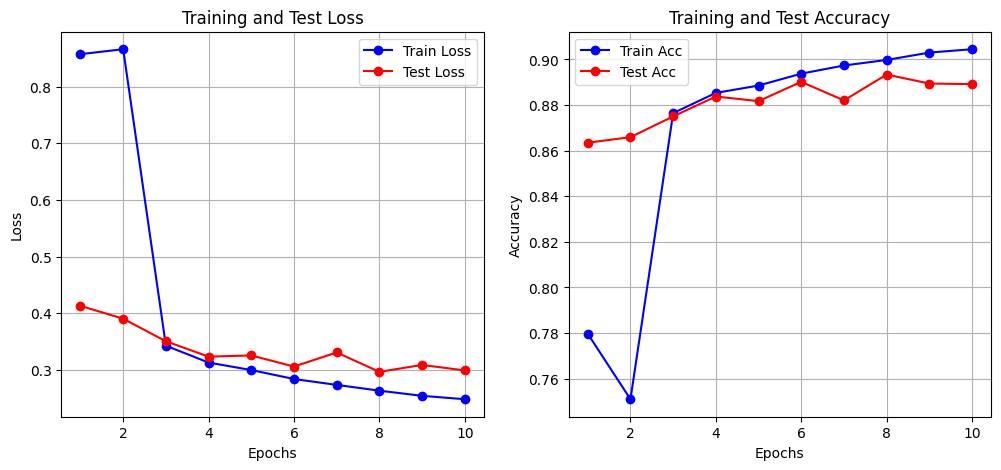

In [17]:
model_name = "ResNet18"
history_resnet = train(net=model,
      train_iter=train_iter,
      test_iter=test_iter,
      trainer=trainer,
      num_epochs=10,
      device=device)

In [ ]:
finalize_model(model_name, model, history_resnet)
del model

#### VGG 16

In [12]:
model = models.vgg16(weights=None)
model.features[0] = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1)
num_classes = len(train_dataset.classes)
in_features = model.classifier[6].in_features
model.classifier[6] = nn.Linear(in_features, num_classes)

model

VGG(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [13]:
trainer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
model_name = "VGG16"
history_vgg16 = train(net=model,
      train_iter=train_iter,
      test_iter=test_iter,
      trainer=trainer,
      num_epochs=10,
      device=device)

Начинаем обучение на cuda
--------------------
Эпоха 1, loss 0.7023, train acc 0.782, test acc 0.874, time 1327.7 sec


KeyboardInterrupt: 

In [15]:
finalize_model(model_name, model, history_vgg16)
del model

NameError: name 'finalize_model' is not defined

### 4. Оценка результатов

In [19]:
df_results = pd.DataFrame(results_list)
print(df_results)

      Model  Train Loss  Train Acc  Test Loss  Test Acc
0  ResNet18    0.247984   0.904459   0.298836  0.889149
